# NeRF InstantNGP from COLMAP Reconstruction

Train a **NeRF** (neural radiance field) -> InstantNGP directly from the camera poses and sparse point cloud produced by the **previously ran COLMAP SfM pipeline**.

### Pipeline overview
1. **Load** COLMAP binary model (`cameras.bin`, `images.bin`, `points3D.bin`)
2. **Build dataset** – load images, compute camera-to-world matrices, normalise scene, pre-compute rays
3. **Train** – InstantNGP training
4. **Render** – synthesise novel views and a depth map
5. **Save** – write rendered images to disk

## 1. Setup

In [1]:
import sys
import os
from pathlib import Path

# Make the utils/ folder importable
REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT / "utils"))

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import imageio
import time

from nerf import SimpleNeRFTrainer, pose_spherical, colmap_to_c2w, colmap_intrinsics
from colmap import load_colmap_bin_model

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Using device: cuda


## 2. Configuration

Set paths and hyper-parameters here.  
`SCALE_FACTOR` trades image resolution for training speed (`0.25` → 4× faster).  
`RENDER_EVERY` controls how often a validation preview is rendered inline during training.


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Change these to point at a different COLMAP reconstruction / image folder.
COLMAP_DIR = str(REPO_ROOT / "results" / "colmap_miniature" / "0")
IMAGE_DIR  = str(REPO_ROOT / "data" / "images" / "miniature")
OUTPUT_DIR = str(REPO_ROOT / "results" / "nerf_miniature")

# ── Image scale ───────────────────────────────────────────────────────────────
SCALE_FACTOR = 0.5          # resize images (< 1 = faster training)
WHITE_BG     = False         # True for objects on white / transparent BGs

# ── Training ──────────────────────────────────────────────────────────────────
N_ITERS      = 70_000        # total training steps
BATCH_SIZE   = 2048          # rays per training step
LR           = 5e-4          # Adam learning rate
LR_DECAY     = 0.1           # final LR = LR * LR_DECAY (exponential over N_ITERS)
LOG_EVERY    = 500           # print loss/PSNR every N steps
RENDER_EVERY = 1_000         # render a validation preview every N steps (0 = off)
N_SAMPLES    = 64            # depth samples per ray during training & inference

# ── Rendering ─────────────────────────────────────────────────────────────────
RENDER_CHUNK = 2048          # rays per forward pass during rendering (lower = less VRAM)

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Config ready.")


Config ready.


## 3. Load COLMAP Model & Explore Poses

In [3]:
cams_dict, images_dict, points_dict = load_colmap_bin_model(COLMAP_DIR)

print(f"Cameras  : {len(cams_dict)}")
print(f"Images   : {len(images_dict)}")
print(f"3-D pts  : {len(points_dict)}")

# Summarise camera models
for cam_id, cam in cams_dict.items():
    K = colmap_intrinsics(cam)
    print(f"\n  Camera {cam_id}: {cam['model']}  {cam['width']}×{cam['height']}")
    print(f"    fx={K[0,0]:.1f}  fy={K[1,1]:.1f}  cx={K[0,2]:.1f}  cy={K[1,2]:.1f}")


Cameras  : 103
Images   : 103
3-D pts  : 20838

  Camera 1: SIMPLE_RADIAL  1920×1080
    fx=3110.2  fy=3110.2  cx=960.0  cy=540.0

  Camera 2: SIMPLE_RADIAL  1920×1080
    fx=3119.3  fy=3119.3  cx=960.0  cy=540.0

  Camera 3: SIMPLE_RADIAL  1920×1080
    fx=3143.5  fy=3143.5  cx=960.0  cy=540.0

  Camera 4: SIMPLE_RADIAL  1920×1080
    fx=3123.3  fy=3123.3  cx=960.0  cy=540.0

  Camera 5: SIMPLE_RADIAL  1920×1080
    fx=3123.9  fy=3123.9  cx=960.0  cy=540.0

  Camera 6: SIMPLE_RADIAL  1920×1080
    fx=3119.1  fy=3119.1  cx=960.0  cy=540.0

  Camera 7: SIMPLE_RADIAL  1920×1080
    fx=3133.8  fy=3133.8  cx=960.0  cy=540.0

  Camera 8: SIMPLE_RADIAL  1920×1080
    fx=3138.0  fy=3138.0  cx=960.0  cy=540.0

  Camera 9: SIMPLE_RADIAL  1920×1080
    fx=3114.0  fy=3114.0  cx=960.0  cy=540.0

  Camera 10: SIMPLE_RADIAL  1920×1080
    fx=3113.2  fy=3113.2  cx=960.0  cy=540.0

  Camera 11: SIMPLE_RADIAL  1920×1080
    fx=3125.1  fy=3125.1  cx=960.0  cy=540.0

  Camera 12: SIMPLE_RADIAL  1920×1080

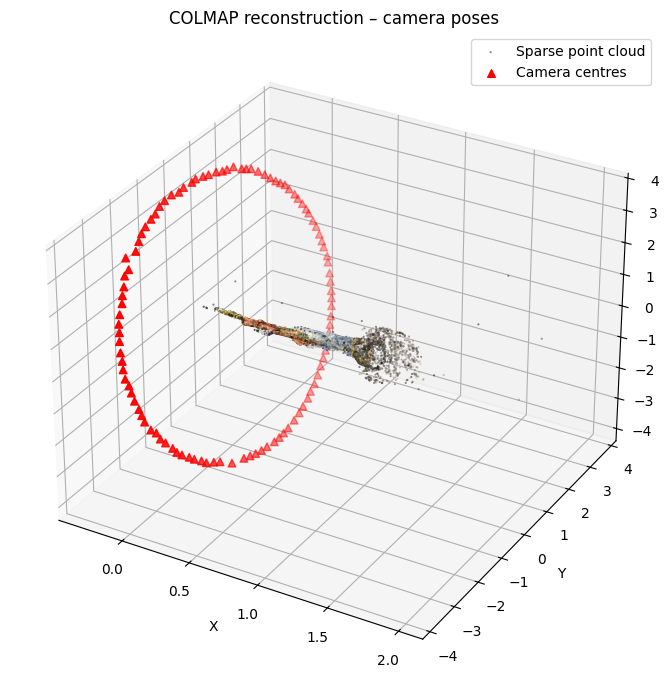


Scene centre : [ 0.00179258 -0.00638008 -0.02248126]
Scene radius : 3.8700


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Build c2w matrices and camera centres
c2w_mats = {}
for img_id, info in images_dict.items():
    c2w_mats[img_id] = colmap_to_c2w(info["qvec"], info["tvec"])

cam_centers = np.stack([m[:3, 3] for m in c2w_mats.values()])
scene_center = cam_centers.mean(axis=0)
scene_scale  = np.linalg.norm(cam_centers - scene_center, axis=-1).max()

# Plot camera positions + sparse point cloud
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection="3d")

if points_dict:
    rng = np.random.default_rng(0)
    pts = np.stack([v["xyz"] for v in points_dict.values()])
    cols = np.stack([v["rgb"] for v in points_dict.values()]) / 255.0
    # Subsample for display
    idx = rng.choice(len(pts), min(8_000, len(pts)), replace=False)
    ax.scatter(pts[idx, 0], pts[idx, 1], pts[idx, 2],
               c=cols[idx], s=0.3, alpha=0.5, label="Sparse point cloud")

ax.scatter(cam_centers[:, 0], cam_centers[:, 1], cam_centers[:, 2],
           c="red", s=30, marker="^", zorder=5, label="Camera centres")
ax.set_title("COLMAP reconstruction – camera poses")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nScene centre : {scene_center}")
print(f"Scene radius : {scene_scale:.4f}")

## 4. Create NeRF Trainer

`SimpleNeRFTrainer` loads the COLMAP binary model internally, builds the dataset
(images, normalised camera poses, per-image intrinsics, near/far planes from the
sparse point cloud), and pre-computes every ray so the training loop only samples
from a pre-built buffer.


In [5]:
trainer = SimpleNeRFTrainer(
    colmap_dir   = COLMAP_DIR,
    image_dir    = IMAGE_DIR,
    output_dir   = OUTPUT_DIR,
    scale_factor = SCALE_FACTOR,
    white_bg     = WHITE_BG,
    device       = DEVICE,
)

print(f"\nModel parameters : {sum(p.numel() for p in trainer.model.parameters()):,}")
print(f"Total training rays: {trainer._rays_o.shape[0]:,}")


Using device: cuda
[ColmapNeRFDataset] 103 images (960×540)  near=0.855  far=1.164  scene_scale=3.8700
Loaded 103 images (960×540)
Intrinsics (cam 0): fx=1555.1 fy=1555.1 cx=480.0 cy=270.0
Near/far: 0.855 / 1.164
Scene centre: [-1.6637219e-09  5.8447274e-08  5.7868588e-10], radius: 2.000
Camera distance range: 0.913 – 1.000

Model parameters : 16,793,796
Total training rays: 53,395,200


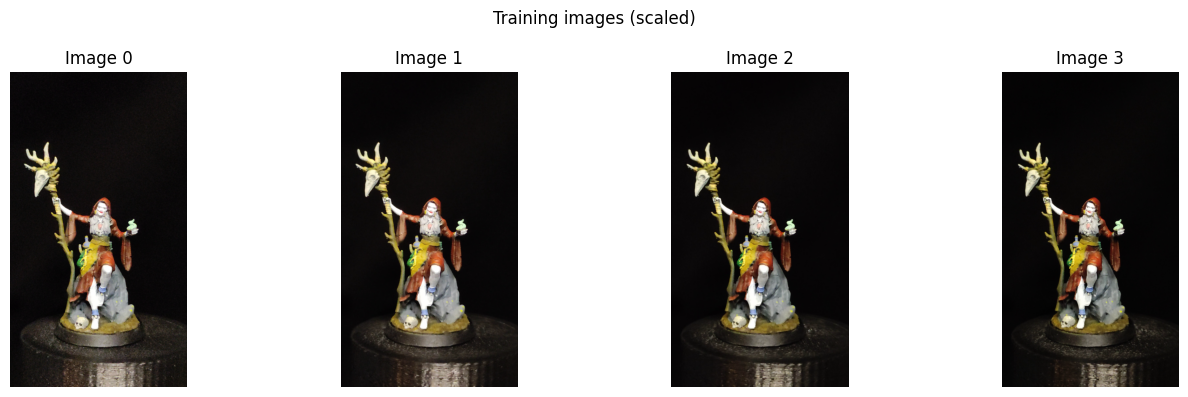

In [6]:
# Quick sanity-check: show first few training images loaded by the trainer
N_show = min(4, trainer.N)
fig, axes = plt.subplots(1, N_show, figsize=(14, 4))
if N_show == 1:
    axes = [axes]
for ax, idx in zip(axes, range(N_show)):
    ax.imshow(trainer.images[idx].cpu().numpy().clip(0, 1))
    ax.set_title(f"Image {idx}")
    ax.axis("off")
plt.suptitle("Training images (scaled)")
plt.tight_layout()
plt.show()


## 5. Train

`trainer.train()` runs the full training loop on the pre-computed ray buffer:

1. Sample `BATCH_SIZE` random rays each step
2. Volume-render with `N_SAMPLES` depth points per ray
3. MSE loss → Adam + exponential LR schedule
4. Every `RENDER_EVERY` steps: render a full validation image inline and save the best
   weights to `nerf_best.pth`

$$\text{PSNR} = -10 \log_{10}(\text{MSE})$$



Training for 70000 steps  |  53,395,200 total rays  |  lr 5.0e-04→5.0e-05


Training:   0%|          | 0/70000 [00:00<?, ?it/s]

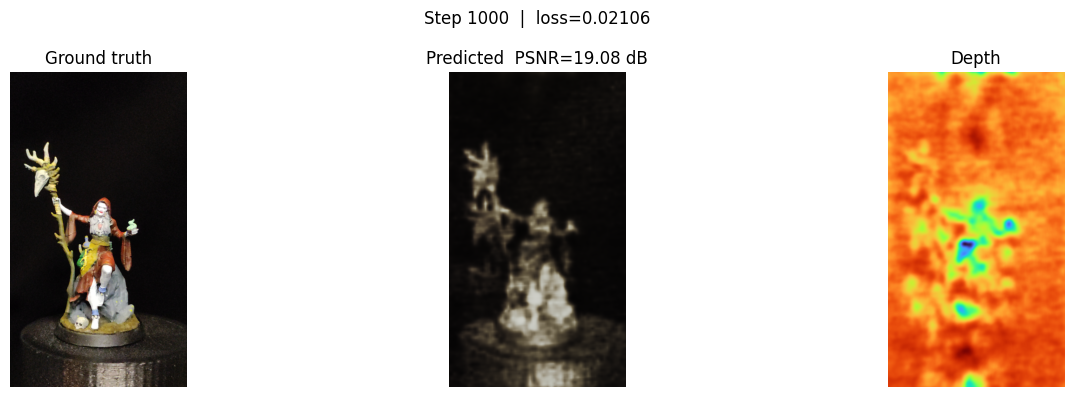

  Saved checkpoint → C:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\results\nerf_miniature\nerf_best.pth  (step=1000, loss=0.02106, PSNR=19.08 dB)


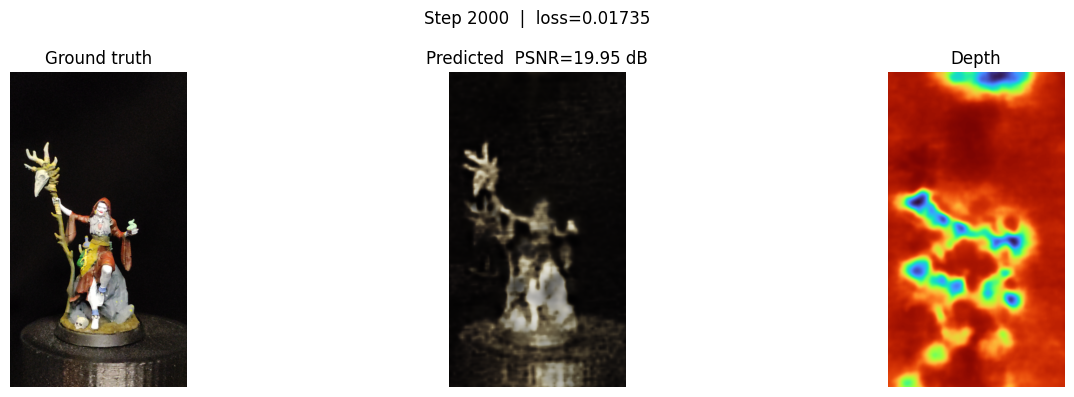

  Saved checkpoint → C:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\results\nerf_miniature\nerf_best.pth  (step=2000, loss=0.01735, PSNR=19.95 dB)


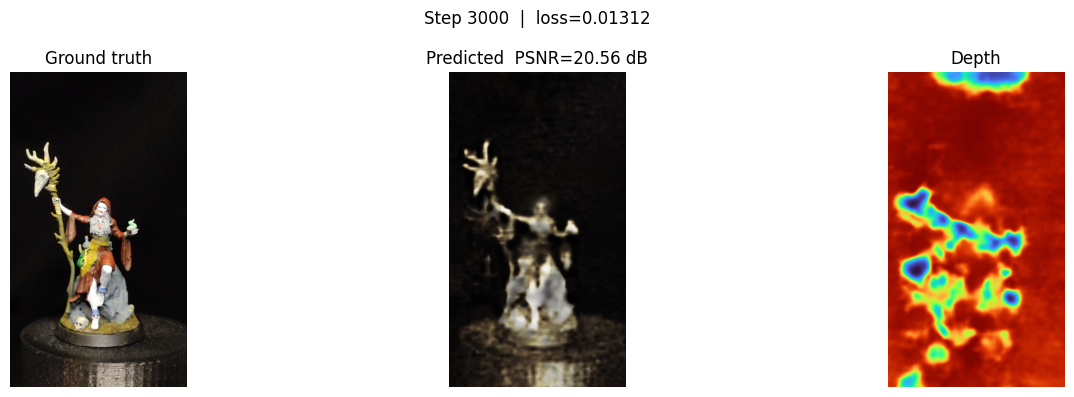

  Saved checkpoint → C:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\results\nerf_miniature\nerf_best.pth  (step=3000, loss=0.01312, PSNR=20.56 dB)


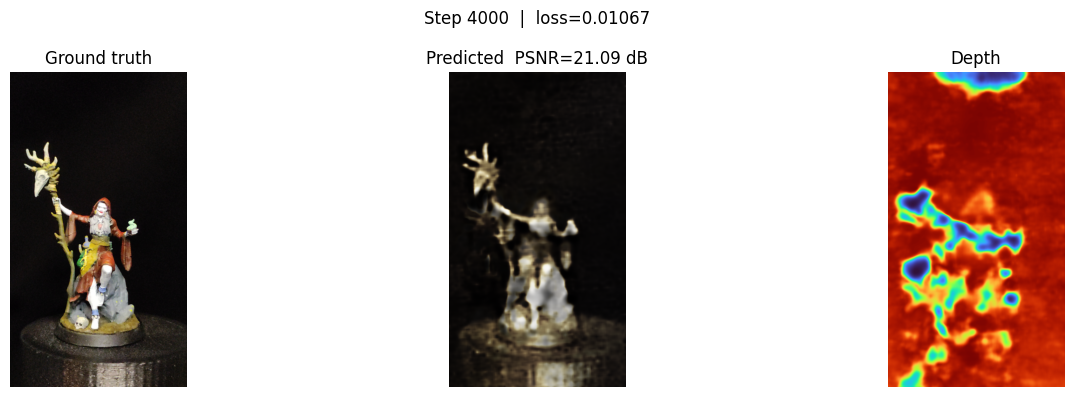

  Saved checkpoint → C:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\results\nerf_miniature\nerf_best.pth  (step=4000, loss=0.01067, PSNR=21.09 dB)


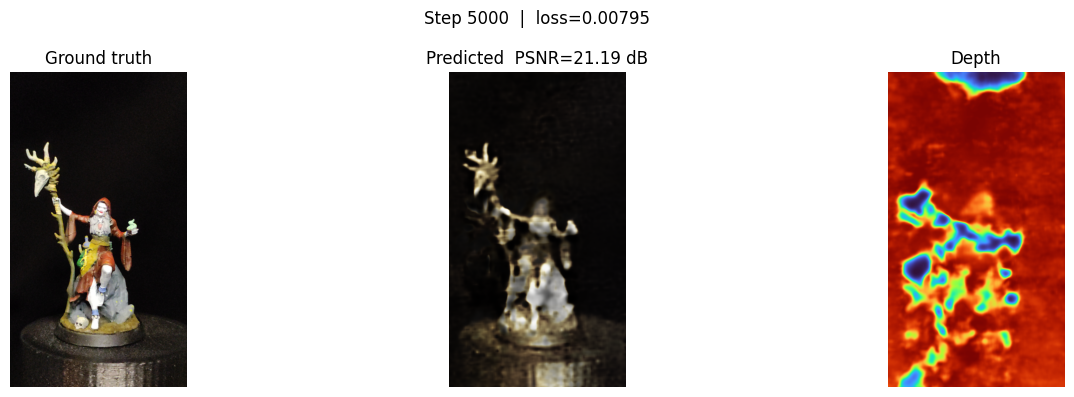

  Saved checkpoint → C:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\results\nerf_miniature\nerf_best.pth  (step=5000, loss=0.00795, PSNR=21.19 dB)


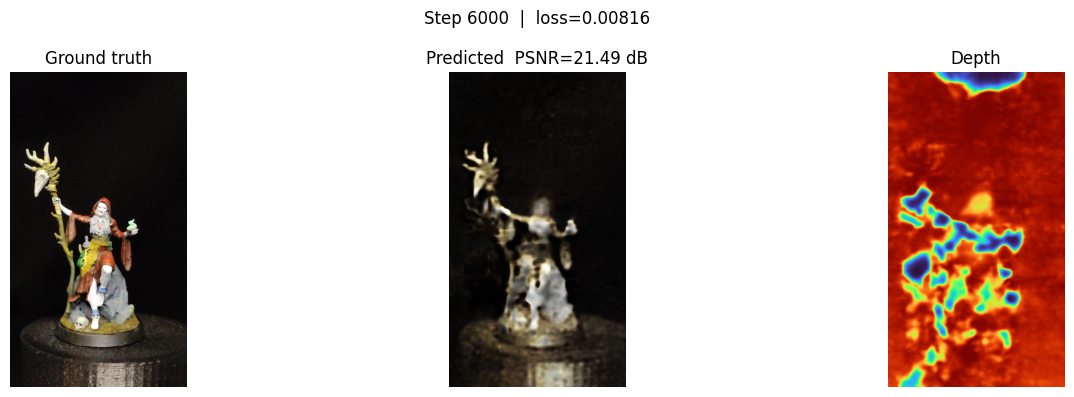

  Saved checkpoint → C:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\results\nerf_miniature\nerf_best.pth  (step=6000, loss=0.00816, PSNR=21.49 dB)


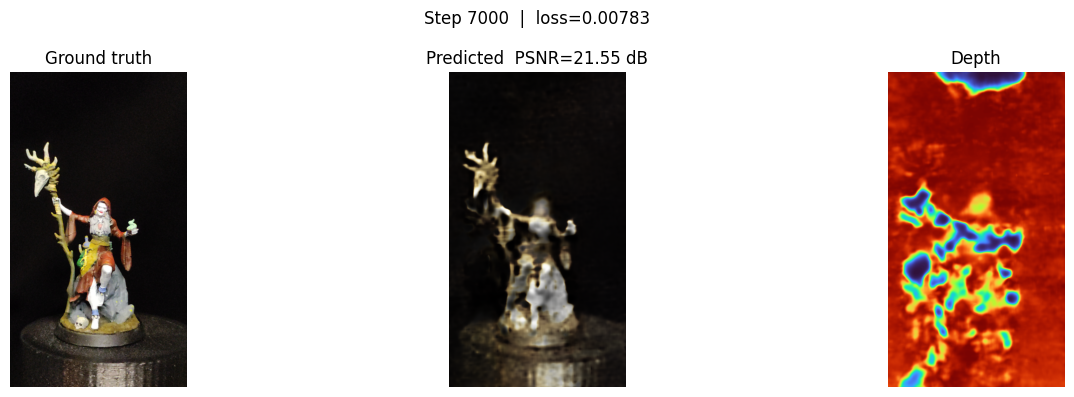

  Saved checkpoint → C:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\results\nerf_miniature\nerf_best.pth  (step=7000, loss=0.00783, PSNR=21.55 dB)


KeyboardInterrupt: 

In [6]:
history = trainer.train(
    n_iters           = N_ITERS,
    batch_size        = BATCH_SIZE,
    lr                = LR,
    lr_decay          = LR_DECAY,
    log_every         = LOG_EVERY,
    preview_every     = RENDER_EVERY,
    preview_index     = 0,           # which dataset image to use for validation previews
    preview_n_samples = N_SAMPLES,
)

## 6. Training Curves


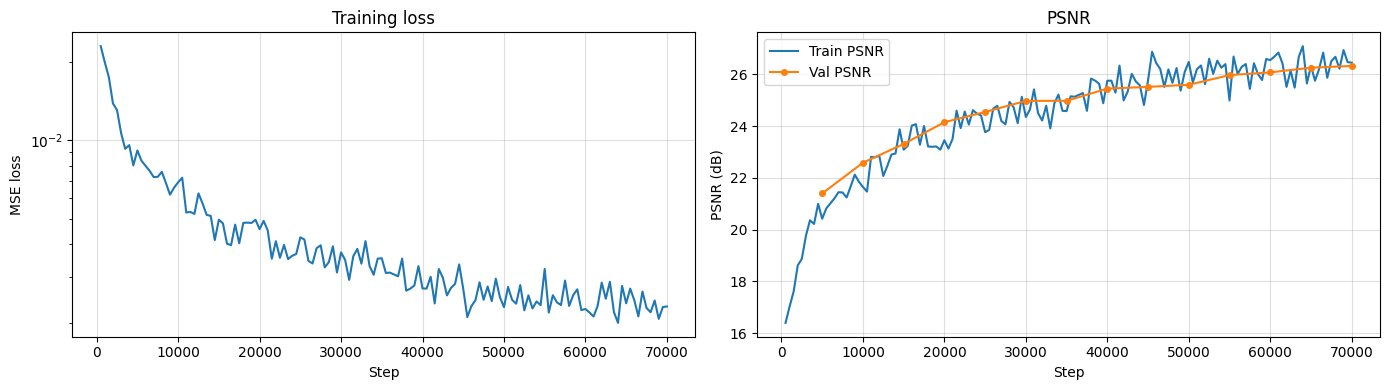

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

steps_logged = np.arange(1, len(history['train_losses']) + 1) * LOG_EVERY
ax1.plot(steps_logged, history['train_losses'])
ax1.set_xlabel("Step"); ax1.set_ylabel("MSE loss")
ax1.set_title("Training loss"); ax1.set_yscale("log"); ax1.grid(True, alpha=0.4)

ax2.plot(steps_logged, history['train_psnrs'], label="Train PSNR")
if history['val_psnrs']:
    ax2.plot(history['val_steps'], history['val_psnrs'],
             label="Val PSNR", marker='o', markersize=4)
ax2.set_xlabel("Step"); ax2.set_ylabel("PSNR (dB)")
ax2.set_title("PSNR"); ax2.legend(); ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


## 7. Synthesise a Novel-View Flyaround

Render novel views by sweeping the camera around a sphere.  Uses `pose_spherical`
to generate 120 poses and `trainer.render_from_pose()` to render each frame with the
trained `SimpleNeRF`.  The resulting RGB and depth videos are saved to `OUTPUT_DIR`.


In [10]:
# Re-encode videos robustly from already-rendered frames
rgb_video   = os.path.join(OUTPUT_DIR, "nerf_360_rgb.mp4")
depth_video = os.path.join(OUTPUT_DIR, "nerf_360_depth.mp4")

def write_mp4(frames, out_path, fps=30):
    # Try H.264 first, then MPEG-4 fallback
    codecs = ["libx264", "mpeg4"]
    last_err = None

    for codec in codecs:
        try:
            with imageio.get_writer(
                out_path,
                format="FFMPEG",
                mode="I",
                fps=fps,
                codec=codec,
                pixelformat="yuv420p",
                macro_block_size=1,
                ffmpeg_log_level="error",
            ) as w:
                for fr in frames:
                    w.append_data(np.ascontiguousarray(fr, dtype=np.uint8))
            if os.path.getsize(out_path) > 0:
                print(f"Saved ({codec}) -> {out_path} [{os.path.getsize(out_path)/1e6:.2f} MB]")
                return
        except Exception as e:
            last_err = e

    raise RuntimeError(f"Failed to write {out_path}. Last error: {last_err}")

rgb_frames = globals().get("frames_rgb", None)
depth_frames = globals().get("frames_depth", None)

if rgb_frames is not None:
    write_mp4(rgb_frames, rgb_video, fps=30)
elif os.path.isfile(rgb_video) and os.path.getsize(rgb_video) > 0:
    print(f"RGB video already exists, skipping encode: {rgb_video}")
else:
    raise NameError("frames_rgb is not defined. Run the flyaround rendering cell first.")

if depth_frames is not None:
    write_mp4(depth_frames, depth_video, fps=30)
elif os.path.isfile(depth_video) and os.path.getsize(depth_video) > 0:
    print(f"Depth video already exists, skipping encode: {depth_video}")
else:
    raise NameError("frames_depth is not defined. Run the flyaround rendering cell first.")

Saved (libx264) -> C:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\results\nerf_miniature\nerf_360_rgb.mp4 [3.99 MB]
Saved (libx264) -> C:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\results\nerf_miniature\nerf_360_depth.mp4 [3.58 MB]


## 8. Extract & Save Mesh

Query the NeRF density field on a regular 3-D grid, then run **marching cubes**
to extract an iso-surface and colour each vertex by querying the fine model's RGB.
The result is saved as a `.ply` file that can be opened in MeshLab, Blender, etc.

> **Tip:** Increase `MESH_RESOLUTION` for a finer mesh (memory doubles with each +64).
> A good `SIGMA_THRESHOLD` depends on the scene; try values between 5 and 50.

In [13]:
import torch.nn.functional as F
from skimage import measure as sk_measure  # scikit-image marching cubes

# ── Mesh extraction settings ─────────────────────────────────────────────────
MESH_RESOLUTION  = 128       # voxels per side (128³ grid)
# SIGMA_THRESHOLD = None → auto-select via percentile (recommended).
# Set to a float to override.
SIGMA_THRESHOLD  = None
SIGMA_PERCENTILE = 97        # top-percentile used when SIGMA_THRESHOLD is None
MESH_QUERY_CHUNK = 65536
MESH_OUT_PATH    = str(Path(OUTPUT_DIR) / "nerf_mesh.ply")

BBOX_MIN = -1.5
BBOX_MAX =  1.5

trainer.model.eval()

print(f"Building {MESH_RESOLUTION}³ density grid …")
lin = torch.linspace(BBOX_MIN, BBOX_MAX, MESH_RESOLUTION, device=DEVICE)
grid_x, grid_y, grid_z = torch.meshgrid(lin, lin, lin, indexing="ij")
pts_grid = torch.stack([grid_x, grid_y, grid_z], dim=-1).reshape(-1, 3)

# Fixed view direction for density queries
dummy_dir = torch.zeros(MESH_QUERY_CHUNK, 3, device=DEVICE)
dummy_dir[..., 2] = -1.0
dummy_dir = dummy_dir / dummy_dir.norm(dim=-1, keepdim=True)

sigma_vals = []
with torch.no_grad():
    for start in range(0, pts_grid.shape[0], MESH_QUERY_CHUNK):
        chunk_pts = pts_grid[start : start + MESH_QUERY_CHUNK]
        n = chunk_pts.shape[0]
        # Normalise positions into the hash-grid domain [-1, 1]
        pts_norm = trainer.normalize_positions(chunk_pts)
        dirs = dummy_dir[:n]
        _, density = trainer.model(pts_norm, dirs)      # density is already softplus'd
        sigma_vals.append(density.squeeze(-1).cpu())

sigma_grid = (
    torch.cat(sigma_vals)
    .reshape(MESH_RESOLUTION, MESH_RESOLUTION, MESH_RESOLUTION)
    .numpy()
)
sigma_grid = np.maximum(sigma_grid, 0)

s_min, s_max = float(sigma_grid.min()), float(sigma_grid.max())
print(f"Density grid: min={s_min:.4f}  max={s_max:.4f}  mean={sigma_grid.mean():.4f}")

if SIGMA_THRESHOLD is None:
    sigma_threshold = float(np.percentile(sigma_grid, SIGMA_PERCENTILE))
    print(f"Auto threshold (p{SIGMA_PERCENTILE}): {sigma_threshold:.4f}")
else:
    sigma_threshold = float(np.clip(SIGMA_THRESHOLD, s_min + 1e-6, s_max - 1e-6))
    print(f"Using threshold: {sigma_threshold:.4f}")

print(f"Voxels above threshold: {(sigma_grid > sigma_threshold).sum():,} / {sigma_grid.size:,}")


Building 128³ density grid …
Density grid: min=0.0004  max=433.1098  mean=0.8688
Auto threshold (p97): 5.7357
Voxels above threshold: 62,915 / 2,097,152


Running marching cubes at threshold=5.7357 …
Mesh: 312,216 vertices  |  469,394 triangles
Colouring vertices …
Mesh saved → C:\Users\gnoceras\Documents\GustavoPersonal\ReconstructionStudies\results\nerf_miniature\nerf_mesh.ply


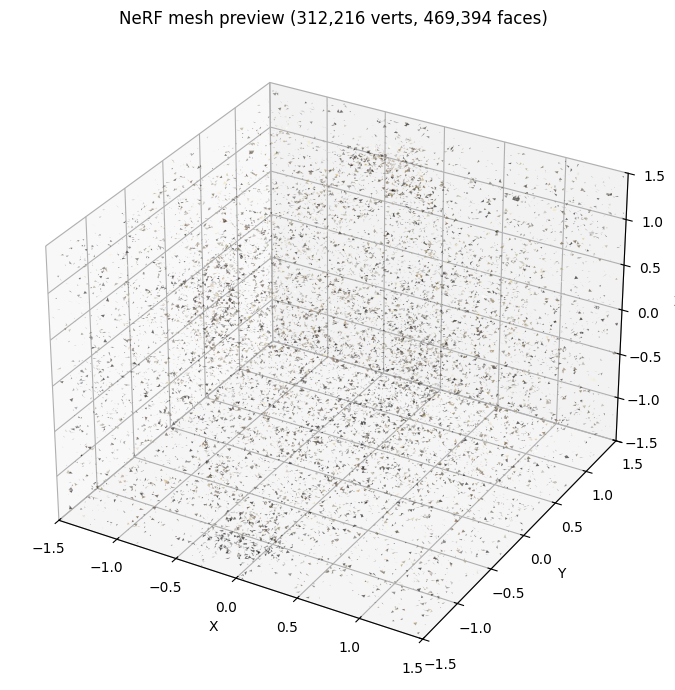

In [14]:
# ── Marching cubes ───────────────────────────────────────────────────────────
print(f"Running marching cubes at threshold={sigma_threshold:.4f} …")
verts_idx, faces, normals, _ = sk_measure.marching_cubes(
    sigma_grid, level=sigma_threshold, allow_degenerate=False
)

# Convert voxel indices → scene-space coordinates
verts_world = verts_idx / (MESH_RESOLUTION - 1) * (BBOX_MAX - BBOX_MIN) + BBOX_MIN

print(f"Mesh: {len(verts_world):,} vertices  |  {len(faces):,} triangles")

# ── Colour vertices by querying the model ────────────────────────────────────
print("Colouring vertices …")
trainer.model.eval()
verts_t   = torch.from_numpy(verts_world.astype(np.float32)).to(DEVICE)
view_dirs = F.normalize(-verts_t, dim=-1)
vert_rgb  = []

with torch.no_grad():
    for start in range(0, verts_t.shape[0], MESH_QUERY_CHUNK):
        v_chunk = verts_t[start : start + MESH_QUERY_CHUNK]
        d_chunk = view_dirs[start : start + MESH_QUERY_CHUNK]
        pts_norm = trainer.normalize_positions(v_chunk)
        rgb_out, _ = trainer.model(pts_norm, d_chunk)   # (N, 3) sigmoid colour
        vert_rgb.append(rgb_out.cpu())

vert_rgb_np = torch.cat(vert_rgb).numpy()               # (V, 3) float in [0, 1]
vert_rgb_u8 = (vert_rgb_np * 255).clip(0, 255).astype(np.uint8)

# ── Write PLY ────────────────────────────────────────────────────────────────
def _write_ply(path: str, verts: np.ndarray, faces: np.ndarray,
               colors: np.ndarray) -> None:
    """Write a coloured triangle mesh as a binary PLY file."""
    import struct
    header = (
        "ply\nformat binary_little_endian 1.0\n"
        f"element vertex {len(verts)}\n"
        "property float x\nproperty float y\nproperty float z\n"
        "property uchar red\nproperty uchar green\nproperty uchar blue\n"
        f"element face {len(faces)}\n"
        "property list uchar int vertex_indices\n"
        "end_header\n"
    )
    with open(path, "wb") as f:
        f.write(header.encode("ascii"))
        for (x, y, z), (r, g, b) in zip(verts.astype(np.float32), colors):
            f.write(struct.pack("<fff", x, y, z))
            f.write(struct.pack("BBB", r, g, b))
        for tri in faces.astype(np.int32):
            f.write(struct.pack("<Biii", 3, tri[0], tri[1], tri[2]))

_write_ply(MESH_OUT_PATH, verts_world, faces, vert_rgb_u8)
print(f"Mesh saved → {MESH_OUT_PATH}")

# ── Quick preview ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection="3d")
rng = np.random.default_rng(42)
idx = rng.choice(len(faces), min(20_000, len(faces)), replace=False)
tri  = verts_world[faces[idx]]
cols = vert_rgb_np[faces[idx]].mean(axis=1)

from mpl_toolkits.mplot3d.art3d import Poly3DCollection
poly = Poly3DCollection(tri, alpha=0.6, linewidth=0)
poly.set_facecolor(cols.clip(0, 1))
ax.add_collection3d(poly)

v = verts_world
ax.set_xlim(v[:, 0].min(), v[:, 0].max())
ax.set_ylim(v[:, 1].min(), v[:, 1].max())
ax.set_zlim(v[:, 2].min(), v[:, 2].max())
ax.set_title(f"NeRF mesh preview ({len(verts_world):,} verts, {len(faces):,} faces)")
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
plt.tight_layout()
plt.savefig(str(Path(OUTPUT_DIR) / "mesh_preview.png"), dpi=120)
plt.show()
